[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/2_qr+lstsq/2_qr+lstsq.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt
from math import *
from scipy.optimize import fsolve
from copy import deepcopy

# Optional: a library for plotting with LaTeX-like 
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

# Unit 2: QR factorization and least squares

## Lecture 14: Gram–Schmidt orthogonalization

### Code demo 1: Gram–Schmidt algorithms

We implement both the classical and modified Gram–Schmidt algorithms and explore their differences in numerical stability.

In [2]:
def cgs(A):
    """
    Compute the QR factorization of a matrix A using the classical Gram-Schmidt process.
    """
    m, n = A.shape
    v = np.zeros((m, n), dtype=np.float64)
    Q = np.zeros((m, n), dtype=np.float64)
    R = np.zeros((n, n), dtype=np.float64)

    for j in range(n):
        vj = A[:, j]
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            vj = vj - R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(vj)
        Q[:, j] = vj / R[j, j]

    return Q, R

In [3]:
def mgs(A):
    """
    Compute the QR factorization of a matrix A using the modified Gram-Schmidt process.
    """
    m, n = A.shape
    v = np.zeros((m, n), dtype=np.float64)
    Q = np.zeros((m, n), dtype=np.float64)
    R = np.zeros((n, n), dtype=np.float64)

    for i in range(n):
        v[:, i] = A[:, i].copy()
    for i in range(n):
        R[i, i] = np.linalg.norm(v[:, i])
        Q[:, i] = v[:, i] / R[i, i]
        for j in range(i+1, n):
            R[i, j] = np.dot(Q[:, i], v[:, j])
            v[:, j] = v[:, j] - R[i, j] * Q[:, i]

    return Q, R

Let us first use `cgs` and `mgs` to compute QR factorization of a matrix, and compare it with library functions.

In [4]:
# Make a random matrix A
seed = 42
dim = 3
np.random.seed(seed) # set random seed for reproducibility
A = np.random.rand(dim, dim)

# QR with classical Gram-Schmidt
Q_cgs, R_cgs = cgs(A)
print(f'Q (CGS):\n{Q_cgs}\n')
print(f'R (CGS):\n{R_cgs}\n')
# QR with modified Gram-Schmidt
Q_mgs, R_mgs = mgs(A)
print(f'Q (MGS):\n{Q_mgs}\n')
print(f'R (MGS):\n{R_mgs}\n')
# QR with NumPy's built-in function
Q_np, R_np = np.linalg.qr(A)
print(f'Q (NumPy):\n{Q_np}\n')
print(f'R (NumPy):\n{R_np}\n')

# Check the orthogonality of Q
orthogonality_cgs = np.allclose(Q_cgs.T @ Q_cgs, np.eye(dim))
orthogonality_mgs = np.allclose(Q_mgs.T @ Q_mgs, np.eye(dim))
print(f'Orthogonality of Q (CGS): {orthogonality_cgs}')
print(f'Orthogonality of Q (MGS): {orthogonality_mgs}')

Q (CGS):
[[ 0.52859931  0.53175347  0.66168045]
 [ 0.84490405 -0.40485392 -0.34961472]
 [ 0.08197508  0.74386259 -0.66328616]]

R (CGS):
[[0.70855204 0.70537257 0.56800835]
 [0.         1.0866969  0.77323229]
 [0.         0.         0.03109683]]

Q (MGS):
[[ 0.52859931  0.53175347  0.66168045]
 [ 0.84490405 -0.40485392 -0.34961472]
 [ 0.08197508  0.74386259 -0.66328616]]

R (MGS):
[[0.70855204 0.70537257 0.56800835]
 [0.         1.0866969  0.77323229]
 [0.         0.         0.03109683]]

Q (NumPy):
[[-0.52859931  0.53175347 -0.66168045]
 [-0.84490405 -0.40485392  0.34961472]
 [-0.08197508  0.74386259  0.66328616]]

R (NumPy):
[[-0.70855204 -0.70537257 -0.56800835]
 [ 0.          1.0866969   0.77323229]
 [ 0.          0.         -0.03109683]]

Orthogonality of Q (CGS): True
Orthogonality of Q (MGS): True


Now let us examine the numerical stability of the two methods. We construct a matrix $A$ with random singular vectors and widely varying singular values spaced by factors of 2 between $2^{-1}$ and $2^{-80}$. Then, we use CGS and MGS to compute QR factorization of $A$.

In [5]:
# Make a random orthogonal matrix U
seed = 21
np.random.seed(seed)  # set random seed for reproducibility
U, _ = np.linalg.qr(np.random.rand(80, 80))
# Make a random orthogonal matrix V
seed = 16
np.random.seed(seed)  # set random seed for reproducibility
V, _ = np.linalg.qr(np.random.rand(80, 80))
# Make singular values from 2^-1 to 2^-80
S = np.diag(2.0**(-1*np.arange(1, 81, 1)))
# Construct A with SVD
A = U @ S @ V.T

In [6]:
# QR with classical Gram-Schmidt
Q_cgs, R_cgs = cgs(A)
# QR with modified Gram-Schmidt
Q_mgs, R_mgs = mgs(A)

Finally, we plot the diagonal elements $r_{jj}$ produced by both computations. Since $r_{jj} = \|P_j a_j\|$, this gives us a picture of the size of the projection at each step.

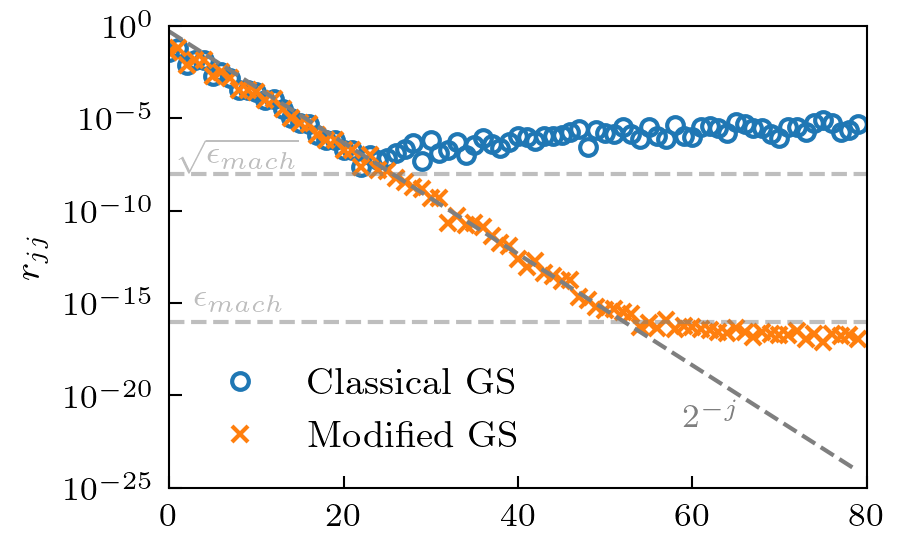

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2), dpi=300)

# Plot singular values
ax.semilogy(np.diag(R_cgs), 'o', ms=4, color='tab:blue', mfc='none', label='Classical GS')
ax.semilogy(np.diag(R_mgs), 'x', ms=4, color='tab:orange', label='Modified GS')
# Plot errors and scaling line
fr = [2**(-k) for k in range(1, 81)]
ax.semilogy(fr, '--', color='tab:gray')
ax.hlines(1e-8, 0, 80, colors='tab:gray', linestyles='--', alpha=0.5)
ax.hlines(1e-16, 0, 80, colors='tab:gray', linestyles='--', alpha=0.5)

# Formatting
ax.set_ylabel('$r_{jj}$', fontsize=9)
ax.legend(loc='lower left', fontsize=9)
ax.text(8, 1e-8, '$\sqrt{\epsilon_{mach}}$', fontsize=8, color='tab:gray', ha='center', va='bottom', alpha=0.5)
ax.text(8, 10.0**(-15.5), '$\epsilon_{mach}$', fontsize=8, color='tab:gray', ha='center', va='bottom', alpha=0.5)
ax.text(62, 1e-22, '$2^{-j}$', fontsize=8, color='tab:gray', ha='center', va='bottom')
# Prettify
ax.set_xlim(0, 80)
ax.set_ylim(1e-25, 1)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
# Save figure
# plt.savefig('results/gram_schmidt.pdf', bbox_inches='tight', transparent=True)
plt.show()

The geometric decrease of $r_{jj}$ does not continue all the way to $j=80$. This is a consequence of rounding errors on the computer. With the classical Gram–Schmidt algorithm, the number never become smaller than about $10^{-8}$. With the modified Gram–Schmidt algorithm, they shrink eight orders of magnitude further, down to the order of $10^{-16}$, which is the level of machine epsilon for the computer.

The rounding error in classical Gram–Schmidt enters during the projection step. Each vector $a_j$ is orthogonalized by subtracting a linear combination of the previously computed $q_i$,
$$
v_j = a_j - \sum_{i=1}^{j-1} (q_i^{\mathsf{T}}a_j)q_i.
$$
In exact arithmetic, this removes all components of $a_j$ in the directions of the earlier $q_i$. However, in float point arithmetic, the compute vectors $q_i$ are only approximately orthogonal. When the projections are formed using the original $a_j$, small components in the directions of the earlier $q_i$ are not fully removed. These residual components are then carried into later steps and can be re-introduced by subsequent projections. This loss of orthogonality causes cancellation and limits how small $r_{jj}$ can become, producing the observed error floor around $10^{-8}$.

Modified Gram–Schmidt avoids this by updating the working vector after each projection,
$$
v_j^{(i+1)} = v_j^{(i)} - (q_i^{\mathsf{T}}a_j)q_i,
$$
so each coefficient is computed from the already deflated vector. This prevents previously removed components from reappearing and allows the diagonal entries $r_{jj}$ to decrease down to machine precision.